In [10]:
import ee
import geemap

# Install geemap if not already installed
# uncomment the line below and run it if you haven't installed geemap
# !pip install geemap

In [11]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='your-project-id') # Replace 'your-project-id' with your Earth Engine project ID if you have one, or remove the project argument to use the default.

In [18]:
dataset = ee.ImageCollection('ECMWF/ERA5/HOURLY').filter(ee.Filter.date('2020-07-01', '2020-08-01'))

visualization = {
  'bands': ['temperature_2m'],
  'min': 250.0,
  'max': 320.0,
  'palette': [
    '000080', '0000d9', '4000ff', '8000ff', '0080ff', '00ffff',
    '00ff80', '80ff00', 'daff00', 'ffff00', 'fff500', 'ffda00',
    'ffb000', 'ffa400', 'ff4f00', 'ff2500', 'ff0a00', 'ff00ff',
  ]
}

m = geemap.Map(center=[21.2, 22.2], zoom=3)
m.add_ee_layer(dataset.first(), visualization, 'Air temperature [K] at 2m height')
m

Map(center=[21.2, 22.2], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [15]:
# Define Indonesia's boundary using a reliable public dataset
countries = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
indonesia_geometry = countries.filter(ee.Filter.eq('country_na', 'Indonesia')).geometry()

# Optionally, visualize the Indonesia boundary
# m.addLayer(indonesia_geometry, {'color': 'red'}, 'Indonesia Boundary')

In [16]:
# Define Indonesia's boundary using a reliable public dataset. This is included here
# to ensure the geometry is correctly loaded even if prior cells are not run.
countries = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
indonesia_geometry = countries.filter(ee.Filter.eq('country_na', 'Indonesia')).geometry()

# Select the first image from the dataset
first_image = dataset.first()

# Clip the image to the Indonesia boundary
clipped_image = first_image.clip(indonesia_geometry)

# Create a new map to display the clipped image
m_clipped = geemap.Map(center=[0, 110], zoom=4) # Centered over Indonesia
m_clipped.add_ee_layer(clipped_image, visualization, 'Air temperature [K] in Indonesia')
m_clipped

Map(center=[0, 110], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

### Calculate Average Temperature for Indonesia

Now let's calculate the average temperature for the entire Indonesia region using `ee.Image.reduceRegion`.


In [17]:
# Define the reducer to calculate the mean temperature
mean_reducer = ee.Reducer.mean()

# Define the scale in meters. ERA5 data resolution is approximately 0.25 degrees, which is about 27.8 km at the equator.
# Using 11132 meters (approx 10km) as a conservative scale for reduction.
# Adjust this scale if you need a more precise aggregation depending on the data's native resolution.
scale_in_meters = 11132

# Calculate the mean temperature over the indonesia_geometry
average_temperature = clipped_image.reduceRegion(
    reducer=mean_reducer,
    geometry=indonesia_geometry,
    scale=scale_in_meters,
    maxPixels=1e9 # Increase maxPixels to avoid 'computation timed out' errors for large regions
)

# Get the value for the 'temperature_2m' band and convert it to a client-side number
avg_temp_kelvin = average_temperature.get('temperature_2m').getInfo()

# Convert Kelvin to Celsius for better interpretability (K - 273.15 = C)
avg_temp_celsius = avg_temp_kelvin - 273.15

print(f"Average temperature in Indonesia (July 1, 2020) at 2m height: {avg_temp_kelvin:.2f} K ({avg_temp_celsius:.2f} °C)")

Average temperature in Indonesia (July 1, 2020) at 2m height: 297.00 K (23.85 °C)


### Daily Average Temperature Trend for Indonesia (July 2020)

Now, let's calculate the average temperature for each day in July 2020 for the Indonesia region and visualize the trend over the month.


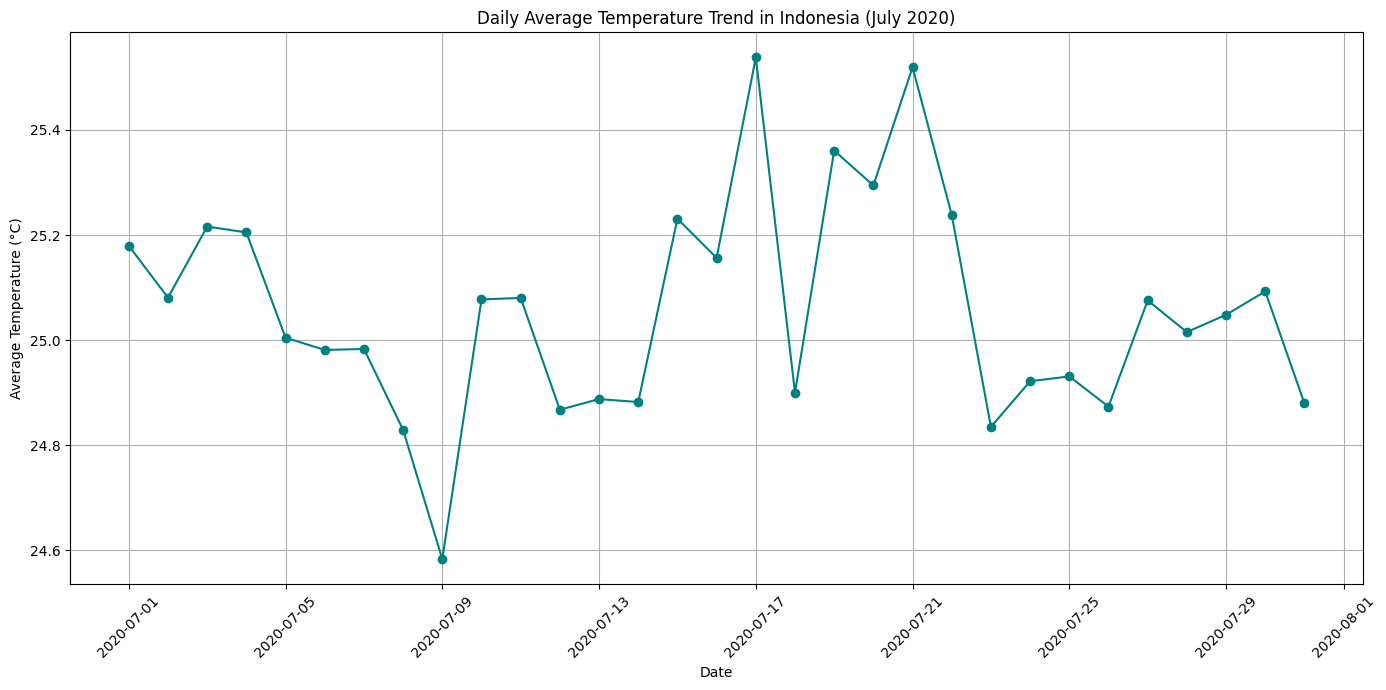

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Generate a list of days in July 2020
start_date_july = ee.Date('2020-07-01')
end_date_july = ee.Date('2020-08-01')

# Create a list of daily dates for July
days = ee.List.sequence(0, end_date_july.difference(start_date_july, 'day').subtract(1)).map(
    lambda d: start_date_july.advance(d, 'day')
)

# Function to calculate daily mean temperature for Indonesia
def get_daily_avg_temp(date):
    date = ee.Date(date)
    # Filter the hourly collection for the current day
    daily_collection = dataset.filterDate(date, date.advance(1, 'day'))
    # Calculate the mean of the hourly images for the day
    daily_mean_image = daily_collection.mean()

    # Clip to Indonesia and reduce region
    # Use the globally defined indonesia_geometry and scale_in_meters
    daily_mean_clipped = daily_mean_image.clip(indonesia_geometry)

    # Calculate the mean temperature over Indonesia for this day
    average_temp_region = daily_mean_clipped.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=indonesia_geometry,
        scale=scale_in_meters, # Re-using previously defined scale
        maxPixels=1e9
    )
    # Get the temperature value and the date
    temp = average_temp_region.get('temperature_2m')
    return ee.Feature(None, {'date': date.format('YYYY-MM-dd'), 'temperature_2m': temp})

# Map the function over the list of days
daily_temperatures_fc = ee.FeatureCollection(days.map(get_daily_avg_temp))

# Convert to a list of dictionaries for client-side plotting
temperatures_list_raw = daily_temperatures_fc.getInfo()

# Extract dates and temperatures, filtering out entries where temperature_2m might be null
dates = [item['properties']['date'] for item in temperatures_list_raw['features'] if item['properties']['temperature_2m'] is not None]
temps_kelvin = [item['properties']['temperature_2m'] for item in temperatures_list_raw['features'] if item['properties']['temperature_2m'] is not None]

# Convert Kelvin to Celsius
temps_celsius = [t - 273.15 for t in temps_kelvin]

# Create a DataFrame for easier plotting and sorting
df_temps = pd.DataFrame({'Date': pd.to_datetime(dates), 'Temperature_C': temps_celsius})
df_temps = df_temps.sort_values('Date') # Ensure dates are sorted

# Plotting the trend
plt.figure(figsize=(14, 7))
plt.plot(df_temps['Date'], df_temps['Temperature_C'], marker='o', linestyle='-', color='teal')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Daily Average Temperature Trend in Indonesia (July 2020)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()